# Milestone 2: appliance energy prediction
Andy Lopez, Hasan Nawaz, Eliseo Marinez | CSCI 3052U | Fall 2026

We want to see how well different models can estimate household appliance energy use from measurements taken during the same 10-minute period. This is supervised regression: the inputs are measurements and the output is a number in watt-hours (Wh). It is a same-period estimate, rather than a forecast made before those measurements exist.

This notebook covers the data checks, initial exploratory data analysis (EDA), sample inputs and outputs, evaluation plan, and compute plan. Model training starts in Milestone 3.

## Setup
Put this notebook and the CSV in the same folder. Install pandas, numpy, and matplotlib, then restart the kernel and run all cells in order. Exact versions used for this run are printed below.

In [1]:
from pathlib import Path
import hashlib
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

print('Python:', platform.python_version())
print('pandas:', pd.__version__)
print('numpy:', np.__version__)
print('matplotlib:', matplotlib.__version__)
paths = [Path('energydata_complete.csv'), Path('energydata_complete(1).csv')]
data_path = next((p for p in paths if p.is_file()), None)
if data_path is None:
    raise FileNotFoundError('Put energydata_complete.csv beside this notebook.')
raw = pd.read_csv(data_path)
print('File:', data_path.name)
print('SHA-256:', hashlib.sha256(data_path.read_bytes()).hexdigest())
print('Shape:', raw.shape)


Python: 3.12.14
pandas: 2.2.3
numpy: 2.3.5
matplotlib: 3.10.8
File: energydata_complete.csv
SHA-256: e7601453ceb2f346d6d721480d74438422705ce5ac5c504c1addfac540dff413
Shape: (19735, 29)


## Data source and license
Source: [UCI Appliances Energy Prediction](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction).

Candanedo, L. (2017). *Appliances Energy Prediction* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5VC8G

License: [Creative Commons Attribution 4.0](https://creativecommons.org/licenses/by/4.0/). Keep the attribution and license link when sharing the data, and describe changes such as renamed columns and new time features. The SHA-256 above identifies the exact CSV used.

## Data card
| Item | Description |
|---|---|
| One row | One 10-minute measurement period in one low-energy house in Belgium |
| Size | 19,735 rows and 29 columns: one target and 28 potential inputs |
| Coverage | January 11 to May 27, 2016; about 4.5 months |
| Target | Appliances: appliance energy consumption, in Wh |
| Inputs | Timestamp, lighting energy, temperature, humidity, weather, and two random variables |
| Missing values | None found in this copy |
| Main limits | One house, limited months, no direct occupancy information, and uneven target values |
| Intended use | Course proof of concept for estimating same-period energy use |
| Outside scope | Claims about all houses, full-year performance, or causes of energy use |

UCI's collection description says indoor readings were averaged into 10-minute periods and weather observations were merged by timestamp. Any live use would need to check that the weather inputs can actually be obtained at the intended prediction time.


In [2]:
df = raw.copy()
# 3. Rename columns to descriptive names
column_mapping = {
    'date': 'datetime',
    'Appliances': 'appliances_energy_wh',
    'lights': 'lights_energy_wh',
    'T1': 'temp_kitchen_c',
    'RH_1': 'humidity_kitchen_pct',
    'T2': 'temp_living_room_c',
    'RH_2': 'humidity_living_room_pct',
    'T3': 'temp_laundry_c',
    'RH_3': 'humidity_laundry_pct',
    'T4': 'temp_office_c',
    'RH_4': 'humidity_office_pct',
    'T5': 'temp_bathroom_c',
    'RH_5': 'humidity_bathroom_pct',
    'T6': 'temp_outside_north_c',
    'RH_6': 'humidity_outside_north_pct',
    'T7': 'temp_ironing_room_c',
    'RH_7': 'humidity_ironing_room_pct',
    'T8': 'temp_teen_room_c',
    'RH_8': 'humidity_teen_room_pct',
    'T9': 'temp_parents_room_c',
    'RH_9': 'humidity_parents_room_pct',
    'T_out': 'temp_weather_station_c',
    'Press_mm_hg': 'pressure_weather_station_mmhg',
    'RH_out': 'humidity_weather_station_pct',
    'Windspeed': 'windspeed_weather_station_ms',
    'Visibility': 'visibility_weather_station_km',
    'Tdewpoint': 'dewpoint_weather_station_c',
    'rv1': 'random_variable_1',
    'rv2': 'random_variable_2'
}

df = df.rename(columns=column_mapping)


## Feature definitions
Temperatures are in degrees Celsius; humidity is relative humidity in percent. Relative humidity describes how close the air is to holding as much water vapour as it can at that temperature.

The descriptive column names below keep the original variables easy to trace. T6/RH_6 are outdoor sensors, so not all nine sensor pairs are indoor measurements.

In [3]:
rows = []
for original, renamed in column_mapping.items():
    if original == 'date': unit = 'timestamp'
    elif original in ['Appliances', 'lights']: unit = 'Wh'
    elif original.startswith('RH'): unit = '%'
    elif original == 'Press_mm_hg': unit = 'mm Hg'
    elif original == 'Windspeed': unit = 'm/s'
    elif original == 'Visibility': unit = 'km'
    elif original in ['rv1', 'rv2']: unit = 'unitless random control'
    else: unit = 'degrees Celsius'
    rows.append({'original': original, 'descriptive_name': renamed, 'unit': unit})
display(pd.DataFrame(rows))


,original,descriptive_name,unit
0,date,datetime,timestamp
1,Appliances,appliances_energy_wh,Wh
2,lights,lights_energy_wh,Wh
3,T1,temp_kitchen_c,degrees Celsius
4,RH_1,humidity_kitchen_pct,%
5,T2,temp_living_room_c,degrees Celsius
6,RH_2,humidity_living_room_pct,%
7,T3,temp_laundry_c,degrees Celsius
8,RH_3,humidity_laundry_pct,%
9,T4,temp_office_c,degrees Celsius


## Data quality checks
These checks establish the size, date coverage, missing values, duplicate rows, and time spacing. We inspect the full dataset for these structural checks, but use only the training portion for target plots and feature relationships.

In [4]:
df['datetime'] = pd.to_datetime(df['datetime'], errors='raise')
df = df.sort_values('datetime').reset_index(drop=True)
print('Missing values:', int(df.isna().sum().sum()))
print('Duplicate rows:', int(df.duplicated().sum()))
print('Duplicate timestamps:', int(df['datetime'].duplicated().sum()))
print('Start:', df['datetime'].min())
print('End:', df['datetime'].max())
print('Time intervals:')
print(df['datetime'].diff().dropna().value_counts())
print('rv1 and rv2 identical:', bool((df['random_variable_1'] == df['random_variable_2']).all()))
assert df['datetime'].is_monotonic_increasing
assert not df['datetime'].duplicated().any()
assert df['datetime'].diff().dropna().eq(pd.Timedelta(minutes=10)).all()


Missing values: 0
Duplicate rows: 0
Duplicate timestamps: 0
Start: 2016-01-11 17:00:00
End: 2016-05-27 18:00:00
Time intervals:
datetime
0 days 00:10:00    19734
Name: count, dtype: int64
rv1 and rv2 identical: True


## Train, validation, and test plan
We use the earliest 70% for training, the next 15% for validation, and the final 15% for testing. A chronological split keeps later observations out of earlier training data. Nearby rows can be very similar, so a random split could give an overly favourable estimate of future-period performance.

The test set is reserved for the final evaluation. We will tune within training data using five expanding-window time-series folds, then use the validation block to confirm the selected configuration. We will freeze the final choice before optionally refitting on training plus validation and evaluating the test block once. Scaling, imputation if ever needed, feature selection, and benchmark constants must be fitted using the training rows for that stage only. A scikit-learn Pipeline will keep those steps inside each fold.

There are no lagged target features or rolling windows in the current plan. If we add them, we will document a suitable time gap and check their construction for leakage. Randomized models will use seed 42; row order is never shuffled.

In [5]:
train_end = int(len(df) * 0.70)
validation_end = int(len(df) * 0.85)
train = df.iloc[:train_end].copy()
validation = df.iloc[train_end:validation_end].copy()
test = df.iloc[validation_end:].copy()
split_table = pd.DataFrame([
    {'split': name, 'rows': len(part), 'start': part['datetime'].min(), 'end': part['datetime'].max()}
    for name, part in [('train', train), ('validation', validation), ('test', test)]
])
display(split_table)
assert train['datetime'].max() < validation['datetime'].min()
assert validation['datetime'].max() < test['datetime'].min()


,split,rows,start,end
0,train,13814,2016-01-11 17:00:00,2016-04-16 15:10:00
1,validation,2960,2016-04-16 15:20:00,2016-05-07 04:30:00
2,test,2961,2016-05-07 04:40:00,2016-05-27 18:00:00


## Sample inputs and outputs
We exclude the target from X, remove the two random controls, and turn the timestamp into hour and day-of-week features. Monday is 0 and Sunday is 6. The raw timestamp is not passed to the models.

These are observed labels, not model predictions. For example, the first row has an observed output of 60 Wh. Lighting is included only under the assumption that its same-period measurement is available. We will also compare performance without lighting.

In [6]:
def make_features(part):
    X = part.drop(columns=['appliances_energy_wh', 'datetime', 'random_variable_1', 'random_variable_2']).copy()
    X['hour'] = part['datetime'].dt.hour
    X['day_of_week'] = part['datetime'].dt.dayofweek
    return X

X_train = make_features(train)
y_train = train['appliances_energy_wh'].copy()
print('Predictor count:', X_train.shape[1])
print('Sample inputs (all model columns):')
print(X_train.head(3).to_string(index=False))
print('Matching observed outputs, Wh:', y_train.head(3).tolist())
assert 'appliances_energy_wh' not in X_train.columns


Predictor count: 27
Sample inputs (all model columns):
 lights_energy_wh  temp_kitchen_c  humidity_kitchen_pct  temp_living_room_c  humidity_living_room_pct  temp_laundry_c  humidity_laundry_pct  temp_office_c  humidity_office_pct  temp_bathroom_c  humidity_bathroom_pct  temp_outside_north_c  humidity_outside_north_pct  temp_ironing_room_c  humidity_ironing_room_pct  temp_teen_room_c  humidity_teen_room_pct  temp_parents_room_c  humidity_parents_room_pct  temp_weather_station_c  pressure_weather_station_mmhg  humidity_weather_station_pct  windspeed_weather_station_ms  visibility_weather_station_km  dewpoint_weather_station_c  hour  day_of_week
               30           19.89             47.596667                19.2                 44.790000           19.79             44.730000      19.000000            45.566667        17.166667                  55.20              7.026667                   84.256667                 17.2                  41.626667              18.2               48

## Initial EDA: training data only
EDA means looking at the data before modelling so we understand its shape and possible problems. We start with numeric summaries and check basic physical ranges. A valid range does not prove every sensor reading is correct.

In [7]:
display(train.select_dtypes(include='number').describe().T)
humidity_cols = [c for c in train if c.startswith('humidity_')]
print('Training humidity readings outside 0-100%:', int(((train[humidity_cols] < 0) | (train[humidity_cols] > 100)).sum().sum()))
print('Negative training energy readings:', int((train[['appliances_energy_wh', 'lights_energy_wh']] < 0).sum().sum()))
print('Non-finite training numeric values:', int((~np.isfinite(train.select_dtypes(include='number'))).sum().sum()))
print('Target summary:')
print(y_train.describe(percentiles=[0.50, 0.90, 0.95, 0.99]))


,count,mean,std,min,25%,50%,75%,max
appliances_energy_wh,13814.0,98.775156,106.857292,10.000000,50.000000,60.000000,100.000000,1080.000000
lights_energy_wh,13814.0,4.551904,8.616680,0.000000,0.000000,0.000000,10.000000,70.000000
temp_kitchen_c,13814.0,21.069756,1.242105,16.790000,20.290000,21.200000,22.000000,24.100000
humidity_kitchen_pct,13814.0,40.403839,3.555143,31.426667,37.700000,40.090000,43.133333,63.360000
temp_living_room_c,13814.0,19.584244,1.485123,16.100000,18.566667,19.500000,20.600000,24.600000
humidity_living_room_pct,13814.0,40.881499,3.255742,30.160000,38.663333,40.966667,43.427679,50.363333
temp_laundry_c,13814.0,21.418166,1.465726,17.200000,20.390000,21.390000,22.390000,26.700000
humidity_laundry_pct,13814.0,39.798476,3.126425,32.626667,37.500000,39.090000,42.254000,50.163333
temp_office_c,13814.0,19.960589,1.469368,15.100000,19.100000,20.100000,21.000000,23.760000
humidity_office_pct,13814.0,39.465291,4.241896,30.723333,36.200000,38.863333,42.500000,51.090000


Training humidity readings outside 0-100%: 0
Negative training energy readings: 0
Non-finite training numeric values: 0
Target summary:
count    13814.000000
mean        98.775156
std        106.857292
min         10.000000
50%         60.000000
90%        220.000000
95%        340.000000
99%        590.000000
max       1080.000000
Name: appliances_energy_wh, dtype: float64


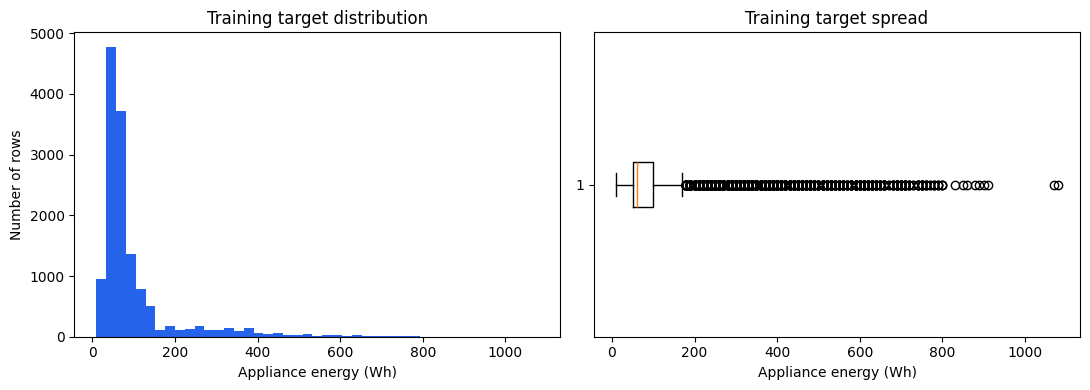

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(y_train, bins=45, color='#2563eb')
axes[0].set(xlabel='Appliance energy (Wh)', ylabel='Number of rows', title='Training target distribution')
axes[1].boxplot(y_train, vert=False)
axes[1].set(xlabel='Appliance energy (Wh)', title='Training target spread')
fig.tight_layout()
plt.show()


Most periods have lower energy use, with a smaller number of large spikes. This is called a right-skewed distribution: the high values stretch the right side of the graph. Large values will be retained unless there is evidence they are measurement errors. They may represent real appliance activity.

MAE describes the average absolute prediction error in Wh. RMSE will also be reported because it gives more weight to large errors and helps show whether a model misses those spikes.

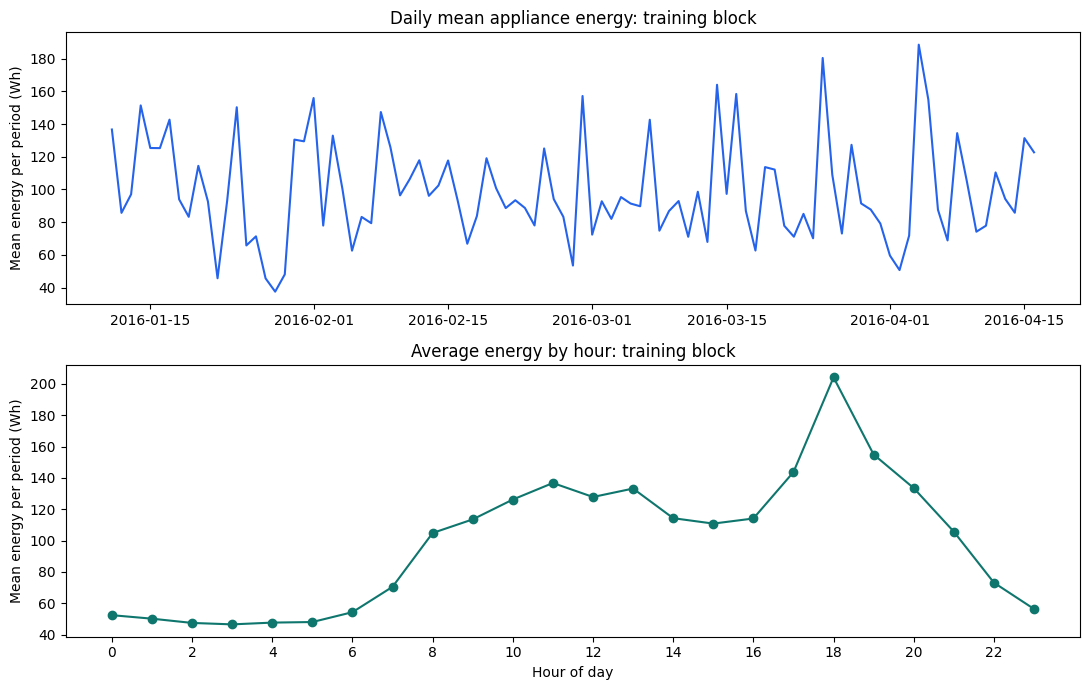

Training mean by day of week (Monday=0):
datetime
0    124.08
1     92.72
2     94.55
3     90.19
4     96.25
5     99.65
6     95.01
Name: appliances_energy_wh, dtype: float64
Highest mean hour: 18 Lowest mean hour: 3


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7))
daily = train.set_index('datetime')['appliances_energy_wh'].resample('D').mean()
axes[0].plot(daily.index, daily.values, color='#2563eb')
axes[0].set(ylabel='Mean energy per period (Wh)', title='Daily mean appliance energy: training block')
by_hour = train.groupby(train['datetime'].dt.hour)['appliances_energy_wh'].mean()
axes[1].plot(by_hour.index, by_hour.values, marker='o', color='#0f766e')
axes[1].set(xlabel='Hour of day', ylabel='Mean energy per period (Wh)', title='Average energy by hour: training block', xticks=range(0,24,2))
fig.tight_layout()
plt.show()
print('Training mean by day of week (Monday=0):')
print(train.groupby(train['datetime'].dt.dayofweek)['appliances_energy_wh'].mean().round(2))
print('Highest mean hour:', int(by_hour.idxmax()), 'Lowest mean hour:', int(by_hour.idxmin()))


Energy use changes across hours and days, which gives us a reason to test time features. These averages describe the training period only. They do not prove that the same pattern will hold later or in another house.

,correlation_with_target
hour,0.231803
lights_energy_wh,0.225525
temp_living_room_c,0.149626
humidity_weather_station_pct,-0.147125
temp_laundry_c,0.121399
humidity_teen_room_pct,-0.115910
temp_outside_north_c,0.108138
temp_weather_station_c,0.092834
humidity_kitchen_pct,0.089316
temp_kitchen_c,0.083939


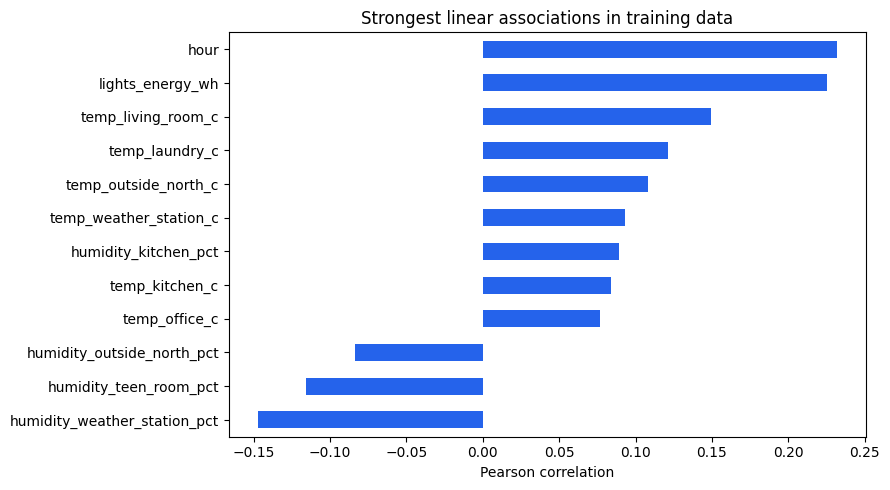

In [10]:
correlations = X_train.corrwith(y_train).sort_values(key=lambda s: s.abs(), ascending=False)
display(correlations.rename('correlation_with_target').to_frame())
fig, ax = plt.subplots(figsize=(9, 5))
correlations.head(12).sort_values().plot.barh(ax=ax, color='#2563eb')
ax.set(xlabel='Pearson correlation', title='Strongest linear associations in training data')
fig.tight_layout()
plt.show()


Correlation measures how two values move together in a straight-line pattern. It is a useful first check, but a weak correlation does not rule out a nonlinear relationship. It also does not show that a feature causes energy use.

The two random columns are identical in this copy. They were included as noise controls in the source dataset, so we exclude both from the main models. We may add one back in a separate sensitivity check, but we will not treat it as a useful real-world measurement.

## Models, metric, and success criterion
We will compare a training-mean benchmark, a training-median benchmark, linear regression, kNN regression, a decision tree, and a random forest. The median benchmark is useful because the median gives the lowest absolute error among constant predictions. kNN needs scaling; all scaling will be fitted within the training pipeline.

Our primary metric is MAE in Wh, fixed before model selection. We will also report RMSE and R². The empirical success criterion is a lower final-test MAE than both constant benchmarks, supported by validation-fold variability and error analysis. We will report the percentage improvement rather than claiming a particular error reduction in advance. If the models do not beat the benchmarks, that is still a result to explain.

Planned sensitivity checks: compare environmental/weather inputs, temporal inputs, and their combination; compare the full model with and without lighting. We will examine errors during high-consumption periods to see whether average performance hides missed spikes.

## Risks and limits
- One house and part of one year cannot establish performance for other homes or all seasons.
- Adjacent observations are related; chronological splitting and time-ordered tuning reduce overlap across time.
- Same-period inputs must actually be available for the claimed use. This project does not establish ahead-of-time forecasting.
- Occupancy and appliance activity are not directly measured, so important influences may be missing.
- Large consumption spikes may be difficult to predict. We will inspect their errors instead of deleting them for better scores.
- Predictive relationships do not establish cause and effect. This is not evidence that changing room temperature will change appliance use.

## Feasibility and compute plan
The raw CSV is about 12 MB, and there are fewer than 20,000 rows. We plan to use an ordinary CPU laptop with at least 8 GB RAM and Python, pandas, numpy, matplotlib, scikit-learn, and Jupyter. No GPU or paid cloud service is planned; actual team hardware will be recorded before training.

Initial search limits: kNN k in {5, 15, 30} and weights in {uniform, distance}; tree maximum depth in {5, 10, None} and minimum leaf size in {5, 20}; random forest 100 trees with the same depth and leaf options. Each tuned model starts with six configurations and five time-series folds. Linear regression has no tuning grid. Model-specific differences will be documented. We will record elapsed time and reduce the search if needed, documenting any change before inspecting the test results.

## Repository
[GitHub repository](https://github.com/AndyLopezCoding/MachineLearningProject)

## AI assistance
AI helped with brainstorming ideas, organizing the notebook, answering code-related questions, and clarifying scientific terminology and phrasing. The team remained responsible for the final wording and code. No AI-generated code was copied and pasted into the project.

The notebook outputs were produced by running the code against the CSV included in the repository.
